In [72]:
# This program needs the following inputs for usage:
#-A file which is generated by the program MultiSimulation_Tool_Barahona2026, which generates a .txt file with the detected molecules in the interstellar shock cloud
#and labelled files as simulate_generate. Compulsory as I need to go by every file to compile all the datain the program.
#-FOLLOWING STEPS: 1. Import the directory "location you saved it"/1.Synthetic_Spectra/1.All_MADCUBA_SYNTHETIC (WITHOUT COMPRESSING IT) to JupyterLab in the directories
#you consider. You should change the lines where you see a (CHANGE) mark.
#2. In a new cell (suggestion) put the command "program('statement')". This will lead to different statistical tools
#you can use easily to treat all the data, whereas you can find all the possible statements with the comamnd "help".
#If you want the recap of all the 10 statements, here you have them:
#help, plot_spectra, frequency_lines, mol_detection, density_lines, histogram, subplots_low_lines, zoom_low_lines, zoom_high_lines, gaussian_kde_map
import numpy as np
from numpy.random import randint
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde
from matplotlib.gridspec import GridSpec
from adjustText import adjust_text
def program(string,outputSave=0):
    if string == "help":
        print("""
        ══════════════════════════════════════════════════════════════════════
        MOLECULAR SPECTRA ANALYSIS TOOL
        ══════════════════════════════════════════════════════════════════════
        
        This program allows you to analyze, visualize and process molecular
        spectra from simulated or observational data.
        
        General usage
        ──────────────────────────────────────────────────────────────────────
        program("command")
        
        Save outputs to file:
        program("command", 1)
        
        Available Commands
        ══════════════════════════════════════════════════════════════════════
        
        1) plot_spectra
        ────────────────
        Plots the full summed spectrum.
        
        Parameters:
        (w_units, grid, y_scale, wantzoom)
        
        w_units   → frequency units: Hz | MHz | GHz
        grid      → show grid: 0 (off) | 1 (on)
        y_scale   → axis scale: linear | log
        wantzoom  → manual zoom: 0 (no) | 1 (yes)
        
        
        2) frequency_lines
        ──────────────────
        Detects spectral peaks in the total spectrum.
        
        Parameters:
        (hmin, threshold, distance, prominence, w_units)
        
        hmin        → minimum peak height
        threshold   → minimum threshold
        distance    → minimum distance between peaks
        prominence  → peak prominence
        w_units     → frequency units
        
        
        3) mol_detection
        ────────────────
        Identifies which molecules contribute to each detected peak.
        
        Parameters:
        (molecules_search, error, hmin, threshold, distance, prominence,
         grid, y_scale, w_units, zoom)
        
        molecules_search → "All" or "select"
        error            → tolerance for matching peaks
        zoom             → manual zoom option
        
        
        4) density_lines
        ────────────────
        Computes the density of spectral lines across frequency intervals.

        Parameters:
        (hmin, threshold, distance, prominence, w_units,
         search_method, spacing)

        search_method → "equispace" or "blocks"
        spacing       → interval step size or number of blocks

        
        5) histogram
        ────────────
        Creates a weighted histogram of detected spectral lines.
        
        Parameters:
        (hmin, threshold, distance, prominence, w_units,
         search_method, spacing)
        
        
        6) subplots_low_lines
        ─────────────────────
        Splits the spectrum into windows and analyzes regions with
        low line density.
        
        Parameters:
        (grid, y_scale, intensityaverage_pass,
         hmin, threshold, distance, prominence,
         w_units, search_method, spacing, method)

        method → "max_I", "max_peaks", "weighted"
        
        
        7) zoom_low_lines
        ─────────────────
        Displays zoomed windows corresponding to regions with
        low spectral line density.
        
        
        8) zoom_high_lines
        ──────────────────
        Displays zoomed windows corresponding to regions with
        high spectral line density.
        
        
        9) gaussian_kde_map
        ───────────────────
        Computes a Kernel Density Estimation (KDE) map of the spectrum.
        
        Parameters:
        (w_units, grid, y_scale, gaussian_method)
        
        gaussian_method → KDE bandwidth method (e.g. "scott", "silverman")
        
                    
        ══════════════════════════════════════════════════════════════════════
        Example
        ══════════════════════════════════════════════════════════════════════
                
        program("plot_spectra")
        
        program("frequency_lines")
        
        program("density_lines", outputSave=1)
        
        ══════════════════════════════════════════════════════════════════════
        """)
        return None
    else:
        molecula=[]
        base_datos=[]
        valor=[]
        referencia=[]
        inputText="moleculardata/molecular_gooddata.txt" #(CHANGE)
        inputDirectory="moleculardata" #(CHANGE)
        cloudName="G+0.693-0.027" #(CHANGE)
        nlines=75600 #(CHANGE)
        with open(inputText, "r", encoding="utf-8") as f:
            for lineas in f: #This part depends on the .txt file you're uploading. If you're putting moléecule|database|logN|ref, everything will be OK
                linea=lineas.strip()  
                datos=linea.split("|")
                molecula.append(datos[0])
                base_datos.append(datos[1])
                valor.append(float(datos[2]))
                referencia =datos[3]
        ftot=np.zeros(75600,float)
        Itot=np.zeros(75600,float)
        for k in range(len(molecula)):
            stringer=inputDirectory+"/simulate_generate_"+molecula[k]+".c"
            with open(stringer, "r", encoding="utf-8") as g:
                fvec=[]
                Ivec=[]
                for lineas2 in g:
                    linea = lineas2.strip()
                    if linea.startswith("//") or not linea:
                        continue
                    f,I=linea.split()  
                    fvec.append(float(f))
                    Ivec.append(float(I))
                Ivec=np.array(Ivec,float)
                if len(Ivec) > nlines:
                    Ivec = Ivec[:nlines]
                Itot+=Ivec
        fvec=np.array(fvec,float)
        ftot=np.copy(fvec)
        Itot=np.array(Itot,float)
        if string=="plot_spectra":
            r=input("Want some other parameters to fill the plot? If not, it will be filled by default values. \n")
            if r=="Yes":
                s=input("Please put all the parameters here, separated by commas and without blanks. Check help if you want to fill all with your preferences.\n The parameters for 'plot_spectra' are: \n (w_units,grid,y_scale,wantzoom) \n")
                m=s.split(",")
                print(m)
            elif r=="No":
                m=[]
            default=['GHz',0,'linear',0]
            if m==[]:
                m=np.copy(default)
            if len(m)<len(default):
                t=len(m)
                for k in range(len(default)-t):
                    m.append(default[len(m)+k])
            for n in range(len(m)):
                if n==0:
                    if m[n]=='Hz':
                        plt.plot(fvec,Itot)
                        plt.title("Plot of the spectra of"+cloudName)
                        plt.xlabel("$\\nu$ (Hz)")
                    elif m[n]=='GHz':
                        fvec/=1e+9
                        plt.plot(fvec,Itot)
                        plt.title("Plot of the spectra of "+cloudName)
                        plt.xlabel("$\\nu$ (GHz)")
                    elif m[n]=='MHz':
                        fvec/=1e+6
                        plt.plot(fvec,Itot)
                        plt.title("Plot of the spectra of "+cloudName)
                        plt.xlabel("$\\nu$ (MHz)")
                elif n==1:
                    if m[n]=="False":
                        m[n]=0
                    elif m[n]=="True":
                        m[n]=1
                    if int(m[n])==0: #default
                        plt.grid(False)
                    elif int(m[n])==1:
                        plt.grid(True)
                elif n==2: 
                    if m[n]=='log':
                        plt.yscale(m[n])
                        plt.ylabel("$\\log(T_A^*)$ (K)")
                    elif m[n]=='linear':
                        plt.yscale(m[n])
                        plt.ylabel("$T_A^*$ (K)")
                elif n==3:
                    if m[n]=="1" or m[n]=="true" or m[n]=="True":
                        s=input("Where do you want the zooming? Put the values of xmin, xmax, ymin, ymax. Separate all the values by commas \n")
                        ejes=s.split(",") 
                        plt.axis([float(ejes[0]),float(ejes[1]),float(ejes[2]),float(ejes[3])])
            if outputSave==1:
                plt.savefig("show_spectra_g0693.svg", bbox_inches="tight")
                plt.show()
                print('saved as: %show_spectra_g0693.svg%')
                return None
            else:
                plt.show()
                return None
        elif string=="frequency_lines":
            r=input("Want some other parameters for this tool? If not, it will be filled by default values. \n") 
            if r=="Yes":
                s=input("Please put all the parameters here, separated by commas and without blanks. Check help if you want to fill all with your preferences.\n The parameters for 'frequency_lines' are: \n (hmin,threshold,distance,prominence,w_units) \n")
                m=s.split(",")
                print(m)
            elif r=="No":
                m=[]
            default=[1e-2,0,1,0,'GHz'] 
            if m==[]:
                m=np.copy(default) 
            if len(m)<len(default):
                t=len(m)
                for k in range(len(default)-t):
                    m.append(default[len(m)+k])
            for n in range(len(m)):
                if n==0: 
                    hmin=float(m[n])
                elif n==1:
                    threshold=float(m[n])
                elif n==2: 
                    distance=float(m[n])
                elif n==3: 
                    prom=float(m[n])
                elif n==4:
                    if m[n]=='Hz':
                        continue
                    elif m[n]=='GHz':
                        fvec/=1e+9
                    elif m[n]=='MHz':
                        fvec/=1e+6
            peaks, props = find_peaks(Itot,hmin,threshold,distance,prominence=prom)
            if outputSave==1:
                picos=[]
                for k in peaks:
                    picos.append(fvec[int(k)])
                if m[4]=='Hz':
                    np.savetxt("peaks.txt", picos/1e+9, fmt="%.6f",header="peak_freq (Hz)")
                elif m[4]=='MHz':
                    np.savetxt("peaks.txt", picos/1e+3, fmt="%.6f",header="peak_freq (MHz)")
                elif m[4]=='GHz':
                    np.savetxt("peaks.txt", picos, fmt="%.6f",header="peak_freq (GHz)")
                print('saved as: %peaks.txt%')
                return None
            else:
                for k in peaks:
                    if m[4]=='Hz':
                        print("Obtained a peak in v= %6.3f *10^9 Hz" % (fvec[int(k)]/1e+9))
                    elif m[4]=='MHz':
                        print("Obtained a peak in v= %6.3f *10^3 MHz" % (fvec[int(k)]/1e+3))
                    elif m[4]=='GHz':
                        print("Obtained a peak in v= %6.3f GHz" %fvec[int(k)])
                return None
        elif string=="mol_detection":
            ejes=[]
            r=input("Want some other parameters for this tool? If not, it will be filled by default values. \n")
            if r=="Yes":
                s=input("Please put all the parameters here, separated by commas and without blanks. Check help if you want to fill all with your preferences.\n The parameters for 'mol_detection' are: \n (molecules_search,error,hmin,threshold,distance,prominence,grid,y_scale,w_units,zoom) \n")
                m=s.split(",") 
                print(m)
            elif r=="No":
                m=[]
            default=["All",5e-3,1e-2,0,1,0,0,'linear',"GHz","0"] 
            if m==[]:
                m=np.copy(default)
            if len(m)<len(default):
                t=len(m)
                for k in range(len(default)-t):
                    m.append(default[t+k])
            for n in range(len(m)):
                if n==0:
                    mols=m[n]
                elif n==1: 
                    error=float(m[n])
                elif n==2:
                    hmin=float(m[n])
                elif n==3:
                    threshold=float(m[n])
                elif n==4:
                    distance=float(m[n])
                elif n==5:
                    prom=float(m[n])
                elif n==6:
                    if m[n]=="False":
                        m[n]=0
                    elif m[n]=="True":
                        m[n]=1
                    wantgrid=int(m[n])
                elif n==7:
                    escala=m[n]
                elif n==8:
                    unit=m[n]
                    if m[n]=='Hz':
                        continue
                    elif m[n]=='GHz':
                        fvec/=1e+9
                    elif m[n]=='MHz':
                        fvec/=1e+6
                elif n==9:
                    if m[n]=="1" or m[n]=="true" or m[n]=="True":
                        s=input("Where do you want the zooming? Put the values of xmin, xmax, ymin, ymax. Separate all the values by commas \n")
                        ejes=s.split(",")
                        xmin, xmax = float(ejes[0]), float(ejes[1])
            if ejes==[]:
                if m[8]=='GHz':
                    ejes=[30,51,0,4]
                elif m[8]=='MHz':
                    ejes=[30*1e+3,51*1e+3,0,4.5]
                elif m[8]=='Hz':
                    ejes=[30*1e+9,51*1e+9,0,4.5]
            peaks, props = find_peaks(Itot,hmin,threshold,distance,prominence=prom)
            j=props["peak_heights"]
            listpeaks=[]
            proppeaks=[]
            for c in range(len(j)):
                listpeaks.append(fvec[peaks[c]]) 
                proppeaks.append(j[c])
            if mols=="All":
                plt.figure(1)
                fig, ax = plt.subplots(figsize=(150, 20),dpi=300)
                ax.scatter(listpeaks,proppeaks)
                fsize=8.5
                ax.plot(fvec,Itot,alpha=0.4,color="red")
                ax.axhline(3*threshold,alpha=0.4,color="orange")
                ax.set_title("Plot of the spectra of "+cloudName,fontsize=fsize)
                ax.set_ylabel("$I$ (K)",fontsize=fsize)
                if unit=="Hz":
                    ax.set_xlabel("$\\nu$ (Hz)",fontsize=fsize)
                elif unit=="MHz":
                    ax.set_xlabel("$\\nu$ (MHz)",fontsize=fsize)
                elif unit=="GHz":
                    ax.set_xlabel("$\\nu$ (GHz)",fontsize=fsize)
                if escala=="log":
                    ax.set_yscale('log')
                    fsize=8.5
                    ax.set_ylabel("$\\log(I)$ (K)",fontsize=fsize)
                if wantgrid==1:
                    plt.grid(True)
                texts=[]
                for k in range(len(molecula)): 
                    newregisterfvecmol=[]
                    newregisterIvecmol=[]
                    stringer=inputDirectory+"/simulate_generate_"+molecula[k]+".c" #The .txt file directory and the number of lines, in my case I have 75600 lines
                    with open(stringer, "r", encoding="utf-8") as g: 
                        for lineas2 in g: 
                            linea = lineas2.strip()
                            if linea.startswith("//") or not linea:
                                continue
                            f,I=linea.split()  
                            newregisterfvecmol.append(float(f))
                            newregisterIvecmol.append(float(I))
                        newregisterIvecmol=np.array(newregisterIvecmol,float)
                        if len(newregisterIvecmol) < nlines: 
                            newregisterIvecmol = np.pad(newregisterIvecmol, (nlines - len(newregisterIvecmol))//2,'constant',0)
                        elif len(newregisterIvecmol) > nlines:
                            newregisterIvecmol = newregisterIvecmol[:nlines]
                        peaks, props = find_peaks(newregisterIvecmol,hmin,threshold,distance,prominence=prom)
                        j=props["peak_heights"]
                        for c in range(len(j)):
                            for v in range(len(listpeaks)):
                                if fvec[peaks[c]]==listpeaks[v] and proppeaks[v]>error:
                                    if xmin<=fvec[peaks[c]]<= xmax:
                                        ax.axvline(fvec[peaks[c]],alpha=0.3,color="green",ls='--')
                                        t=ax.text(fvec[peaks[c]],float(ejes[3])-0.1-0.03/4.5*k*(float(ejes[3])-float(ejes[2])),molecula[k],fontsize=fsize,ha='right',va='center',rotation=90,color="green")
                                        texts.append(t)
                adjust_text(texts,ax=ax,only_move={'points':'y', 'text':'y+'},arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))
                plt.axis([float(ejes[0]),float(ejes[1]),float(ejes[2]),float(ejes[3])])
                plt.savefig("spectra_g0693.svg", bbox_inches="tight")
                plt.show()
                if outputSave==1:
                    plt.savefig("spectra_g0693.svg", bbox_inches="tight")
                    plt.show()
                    print('saved as: %spectra_g0693.svg%')
                    return None
                else:
                    plt.show()
                    return None
            elif mols=="select":
                k=input("Which molecules you want to identify from the spectra? Separate them by commas \n")
                mols=k.split(",")
                plt.figure(1)
                fig, ax = plt.subplots(figsize=(150, 20),dpi=300)
                ax.scatter(listpeaks,proppeaks)
                fsize=8.5
                ax.plot(fvec,Itot,alpha=0.4,color="red")
                ax.set_title("Plot of the spectra of "+cloudName,fontsize=fsize)
                ax.set_ylabel("$I$ (K)",fontsize=fsize)
                if unit=="Hz":
                    ax.set_xlabel("$\\nu$ (Hz)",fontsize=fsize)
                elif unit=="MHz":
                    ax.set_xlabel("$\\nu$ (MHz)",fontsize=fsize)
                elif unit=="GHz":
                    ax.set_xlabel("$\\nu$ (GHz)",fontsize=fsize)
                if escala=="log":
                    ax.set_yscale('log')
                    fsize=4
                    ax.set_ylabel("$\\log(I)$ (K)",fontsize=fsize)
                if wantgrid==1:
                    plt.grid(True)
                texts=[]
                cont=0
                freqnew=0
                for t in range(len(mols)):
                    for idx in range(len(molecula)):
                        if mols[t]==molecula[idx]:
                            newregisterfvecmol=[]
                            newregisterIvecmol=[]
                            stringer=inputDirectory+"/simulate_generate_"+molecula[idx]+".c"  # The .txt file directory and the number of lines, in my case I have 75600 lines
                            with open(stringer, "r", encoding="utf-8") as g: 
                                for lineas2 in g: 
                                    linea = lineas2.strip() 
                                    if linea.startswith("//") or not linea:
                                        continue
                                    f,I=linea.split() 
                                    newregisterfvecmol.append(float(f))
                                    newregisterIvecmol.append(float(I))
                                newregisterIvecmol=np.array(newregisterIvecmol,float)
                                if len(newregisterIvecmol) < nlines: 
                                    newregisterIvecmol = np.pad(newregisterIvecmol, (nlines - len(newregisterIvecmol))//2,'constant',0)
                                elif len(newregisterIvecmol) > nlines:
                                    newregisterIvecmol = newregisterIvecmol[:nlines] 
                                peaks, props = find_peaks(newregisterIvecmol,hmin,threshold,distance,prominence=prom)
                                j=props["peak_heights"] 
                                for c in range(len(j)):
                                    for v in range(len(listpeaks)):
                                        if abs(fvec[peaks[c]]-listpeaks[v])<1e-3 and proppeaks[v]>error:
                                            if xmin<=fvec[peaks[c]]<=xmax:
                                                ax.axvline(fvec[peaks[c]],alpha=0.3,color="green")
                                                texto=ax.text(fvec[peaks[c]],float(ejes[3])-0.1-0.03/4.5*idx*(float(ejes[3])-float(ejes[2])),molecula[idx],fontsize=fsize,ha='right',va='center',rotation=90,color="green")
                                                texts.append(texto)
                adjust_text(texts,ax=ax,only_move={'points':'y', 'text':'y+'},arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))
                plt.axis([float(ejes[0]),float(ejes[1]),float(ejes[2]),float(ejes[3])])
                if outputSave==1:
                    plt.savefig("spectra_g0693_selected.svg", bbox_inches="tight")
                    plt.show()
                    print('saved as: %spectra_g0693_selected.svg%')
                    return None
                else:
                    plt.show()
                    return None
        elif string=="density_lines": 
            r=input("Want some other parameters for this tool? If not, it will be filled by default values. \n") 
            if r=="Yes":
                s=input("Please put all the parameters here, separated by commas and without blanks. Check help if you want to fill all with your preferences.\n The parameters for 'density_lines' are: \n (hmin,threshold,distance,prominence,w_units,search_method,distance of arange/number of blocks) \n")
                m=s.split(",") 
                print(m)
            elif r=="No":
                m=[]
            default=[1e-2,0,1,0,'GHz','blocks',20] 
            print(m)
            if len(m)>5:
                if m[5]=="equispace": 
                    if m[4]=="Hz":
                        default.pop(6)
                        default.pop(5)
                        default.append("equispace")
                        default.append(5e+8)
                    elif m[4]=="MHz":
                        default.pop(6)
                        default.pop(5)
                        default.append("equispace")
                        default.append(5e+2)
                    elif m[4]=="GHz":
                        default.pop(6)
                        default.pop(5)
                        default.append("equispace")
                        default.append(0.5)
            if m==[]:
                m=np.copy(default) 
            if len(m)<len(default):
                t=len(m)
                for k in range(len(default)-t): 
                    m.append(default[t+k]) 
            for n in range(len(m)):
                if n==0: 
                    hmin=float(m[n])
                elif n==1: 
                    threshold=float(m[n])
                elif n==2: 
                    distance=float(m[n])
                elif n==3:
                    prom=float(m[n])
                elif n==4:
                    unit=m[n]
                    if m[n]=='Hz':
                        continue
                    elif m[n]=='GHz':
                        fvec/=1e+9
                    elif m[n]=='MHz':
                        fvec/=1e+6
                elif n==5: 
                    if m[n]=="blocks":
                        h=np.linspace(fvec[0],fvec[-1],int(m[6])) 
                    elif m[n]=='equispace':
                        h=np.arange(fvec[0],fvec[-1],float(m[6])) 
            print(m)
            peaks, props = find_peaks(Itot,hmin,threshold,distance,prominence=prom) 
            density=[]
            freq_density=[]
            for i in range(1,len(h)-1): 
                freq_density.append(h[i]) 
                p=0
                for k in range(len(peaks)):
                    if h[i-1]<fvec[peaks[k]]<h[i+1]:
                        p+=1 
                density.append(p/(h[i+1]-h[i-1]))
            if outputSave==1:
                np.savetxt("density_lines.txt", np.column_stack((freq_density, density)), fmt="%.6f",header="freq intensity | density")
                print('saved as: %density_lines.txt%')
                return None
            else:
                return freq_density, density
        elif string=="histogram": 
            r=input("Want some other parameters for this tool? If not, it will be filled by default values. \n")
            if r=="Yes":
                s=input("Please put all the parameters here, separated by commas and without blanks. Check help if you want to fill all with your preferences.\n The parameters for 'histogram' are: \n (hmin,threshold,distance,prominence,w_units,search_method,distance of arange/number of blocks) \n")
                m=s.split(",") 
                print(m)
            elif r=="No":
                m=[]
            default=[1e-2,0,1,0,'GHz','blocks',20]
            if len(m)>5:
                if m[5]=="equispace":
                    if m[4]=="Hz":
                        default.pop(6)
                        default.pop(5)
                        default.append("equispace")
                        default.append(1e+7)
                    elif m[4]=="MHz":
                        default.pop(6)
                        default.pop(5)
                        default.append("equispace")
                        default.append(1e+1)
                    elif m[4]=="GHz":
                        default.pop(6)
                        default.pop(5)
                        default.append("equispace")
                        default.append(0.01)
            if m==[]:
                m=np.copy(default)
            if len(m)<len(default):
                t=len(m)
                for k in range(len(default)-t):
                    m.append(default[t+k])
            for n in range(len(m)):
                if n==0:
                    hmin=float(m[n])
                elif n==1:
                    threshold=float(m[n])
                elif n==2:
                    distance=float(m[n])
                elif n==3:
                    prom=float(m[n])
                elif n==4:
                    unit=m[n]
                    if m[n]=='Hz':
                        continue
                    elif m[n]=='GHz':
                        fvec/=1e+9
                    elif m[n]=='MHz':
                        fvec/=1e+6
                elif n==5:
                    if m[n]=="blocks":
                        h=np.linspace(fvec[0],fvec[-1],int(m[6])) 
                    elif m[n]=='equispace':
                        h=np.arange(fvec[0],fvec[-1],float(m[6])) 
            peaks, props = find_peaks(Itot,hmin,threshold,distance,prominence=prom) 
            j=props["peak_heights"]
            listpeaks=[]
            proppeaks=[]
            for m in range(len(j)):
                listpeaks.append(fvec[peaks[m]])
                proppeaks.append(j[m])
            plt.figure(1)
            plt.hist(listpeaks,bins=h,density=False,weights=proppeaks)
            plt.axhline(3*threshold,alpha=0.4,color="orange")
            plt.title("Histogram with density lines")
            if unit=="Hz":
                plt.xlabel("$\\nu$ (Hz)")
                plt.ylabel("d ($Hz^{-1}$)")
            elif unit=="MHz":
                plt.xlabel("$\\nu$ (MHz)")
                plt.ylabel("d ($MHz^{-1}$)")
            elif unit=="GHz":
                plt.xlabel("$\\nu$ (GHz)")
                plt.ylabel("d ($GHz^{-1}$)")
            if outputSave==1:
                plt.savefig("histogram_spectra_g0693.svg", bbox_inches="tight")
                plt.show()
                print('saved as: %histogram_spectra_g0693.svg%')
                return None
            else:
                plt.show()
                return None
        elif string=="subplots_low_lines":
            r=input("Want some other parameters for this tool? If not, it will be filled by default values. \n")
            if r=="Yes":
                s=input("Please put all the parameters here, separated by commas and without blanks. Check help if you want to fill all with your preferences.\n The parameters for 'subplots_low_lines' are: \n (grid,y_scale,intensityaverage_pass,hmin,threshold,distance,prominence,w_units,search_method,distance of arange/number of blocks) \n")
                m=s.split(",") 
                print(m)
            elif r=="No":
                m=[]
            default=[0,'linear',3,1e-2,0,1,0,'GHz',"max_peaks",'equispace',0.5] 
            if len(m)>9:
                if m[9]=="equispace": 
                    if m[7]=="Hz":
                        default.pop(9)
                        default.pop(9)
                        default.append("equispace")
                        default.append(5e+8)
                    elif m[7]=="MHz":
                        default.pop(9)
                        default.pop(9)
                        default.append("equispace")
                        default.append(500)
                    elif m[7]=="GHz":
                        default.pop(9)
                        default.pop(9)
                        default.append("equispace")
                        default.append(0.5)
            if m==[]:
                m=np.copy(default)
            if len(m)<len(default):
                t=len(m)
                for k in range(len(default)-t):
                    m.append(default[t+k]) 
            for n in range(len(m)):
                if n==0:
                    if m[n]=="False":
                        m[n]=0
                    elif m[n]=="True":
                        m[n]=1
                    wantgrid=int(m[n])
                elif n==1:
                    escala=m[n]
                elif n==2:
                    num=int(m[n])
                elif n==3:
                    hmin=float(m[n])
                elif n==4: #El threshold
                    threshold=float(m[n])
                elif n==5:
                    distance=float(m[n])
                elif n==6:
                    prom=float(m[n])
                elif n==7:
                    unit=m[n]
                    if m[n]=='Hz':
                        continue
                    elif m[n]=='GHz':
                        fvec/=1e+9
                    elif m[n]=='MHz':
                        fvec/=1e+6
                elif n==8:
                    method=m[n] 
                elif n==9:
                    if m[n]=="blocks":
                        h=np.linspace(fvec[0],fvec[-1],int(m[10]))
                    elif m[n]=='equispace':
                        h=np.arange(fvec[0],fvec[-1],float(m[10]))
            peaks, props = find_peaks(Itot,hmin,threshold,distance,prominence=prom)
            j=props["peak_heights"]
            listpeaks=[]
            proppeaks=[]
            for c in range(len(j)):
                listpeaks.append(fvec[peaks[c]])
                proppeaks.append(j[c])
            Iwindows=[]
            freqwindows=[]
            freqpeaks=[]
            if method=="weighted":
                alpha=float(input("Which value of the exponent for the probability distribution do you want? \n"))
            for k in range(1,len(h)):
                arraypeaks=[]
                freqpeakswindow=[]
                for d in range(len(proppeaks)):
                    if h[k-1]<listpeaks[d]<h[k]:
                        arraypeaks.append(proppeaks[d]) 
                        if method=="weighted":
                            freqpeakswindow.append(listpeaks[d]/((proppeaks[d])**alpha))
                Iwindows.append(np.mean(arraypeaks))
                freqwindows.append(len(arraypeaks)) 
                if method=="weighted":
                    freqpeaks.append(np.sum(freqpeakswindow)) 
            freqmeans=[]
            if method=="max_I":
                Inew=np.sort(Iwindows) 
                idx = np.argsort(Iwindows)
                for i in idx:
                     freqmeans.append(h[i])
            elif method=="max_peaks":
                freqnew=np.sort(freqwindows)
                idx = np.argsort(freqwindows)
                for i in idx:
                     freqmeans.append(h[i])
            elif method=="weighted":
                weightnew=np.sort(freqpeaks)
                idx = np.argsort(freqpeaks)
                for i in idx:
                     freqmeans.append(h[i])
            hlist=list(h)
            hlist = freqmeans[:len(h)//3]
            hlist = np.sort(hlist) 
            plt.figure(1)
            plt.plot(fvec,Itot,alpha=0.4,color="green")
            plt.axhline(3*threshold,alpha=0.4,color="orange")
            plt.scatter(listpeaks,proppeaks)
            for k in hlist:
                if m[9]=="blocks":
                    eq=(h[1]-h[0])/2
                    plt.axvspan(k-eq,k+eq, color='r',alpha=0.3)
                elif m[9]=="equispace":
                    eq=float(m[10])/2
                    plt.axvspan(k-eq,k+eq, color='r',alpha=0.3)
            for l in range(len(h)):
                plt.axvline(h[l]-eq,color="r",alpha=0.3,ls="--")
            plt.axvline(h[-1]+eq,color="r",alpha=0.3,ls="--")
            plt.title("Plot of the spectra of " +cloudName)
            plt.ylabel("$T_A^*$ (K)")
            if unit=="Hz":
                plt.xlabel("$\\nu$ (Hz)")
            elif unit=="MHz":
                plt.xlabel("$\\nu$ (MHz)")
            elif unit=="GHz":
                plt.xlabel("$\\nu$ (GHz)")
            if escala=="log":
                plt.yscale('log')
                plt.ylabel("$\\log(T_A^*)$ (K)")
            if wantgrid==1:
                plt.grid(True)
            if outputSave==1:
                plt.savefig("subplots_general_spectra_g0693.svg", bbox_inches="tight")
                plt.show()
                print('saved as: %subplots_general_spectra_g0693.svg%')
            else:
                plt.show()
            n = len(hlist)
            cols = 3
            r=n%cols
            q=n//cols
            rows = n//cols + (1 if r > 0 else 0)
            fig, axs = plt.subplots(rows, cols, figsize=(20, rows*5))
            axs = axs.flatten()
            for i in range(len(axs)):
                if i < n:
                    axs[i].plot(fvec, Itot)
                    axs[i].set_xlim(hlist[i]-eq, hlist[i]+eq)
                    axs[i].set_ylim(0, 0.5)
                    axs[i].axhline(3*threshold, alpha=0.4)
                    axs[i].set_title(f"Window {i+1} of " + cloudName)
                    if escala == "log":
                        axs[i].set_yscale('log')
                        axs[i].set_ylabel("$\\log(T_A^*)$ (K)")
                    if wantgrid == 1:
                        axs[i].grid(True)
                    if unit == "Hz":
                        axs[i].set_xlabel("$\\nu$ (Hz)")
                    elif unit == "MHz":
                        axs[i].set_xlabel("$\\nu$ (MHz)")
                    elif unit == "GHz":
                        axs[i].set_xlabel("$\\nu$ (GHz)")
                else:
                    axs[i].axis('off') 
            if outputSave==1:
                plt.savefig("subplots_lowlines_spectra_g0693.svg", bbox_inches="tight")
                plt.show()
                print('saved as: %subplots_lowlines_spectra_g0693.svg%')
                return None
            else:
                plt.show()
                return None
        elif string=="zoom_low_lines":
            r=input("Want some other parameters for this tool? If not, it will be filled by default values. \n")
            if r=="Yes":
                s=input("Please put all the parameters here, separated by commas and without blanks. Check help if you want to fill all with your preferences.\n The parameters for 'zoom_low_lines' are: \n (grid,y_scale,intensityaverage_pass,hmin,threshold,distance,prominence,w_units,search_method,distance of arange/number of blocks) \n")
                m=s.split(",") 
                print(m)
            elif r=="No":
                m=[]
            default=[0,'linear',3,1e-2,0,1,0,'GHz',"max_peaks",'equispace',0.5] 
            if len(m)>9:
                if m[9]=="equispace": 
                    if m[7]=="Hz":
                        default.pop(9)
                        default.pop(9)
                        default.append("equispace")
                        default.append(5e+8)
                    elif m[7]=="MHz":
                        default.pop(9)
                        default.pop(9)
                        default.append("equispace")
                        default.append(500)
                    elif m[7]=="GHz":
                        default.pop(9)
                        default.pop(9)
                        default.append("equispace")
                        default.append(0.5)
            if m==[]:
                m=np.copy(default)
            if len(m)<len(default):
                t=len(m)
                for k in range(len(default)-t):
                    m.append(default[t+k]) 
            for n in range(len(m)):
                if n==0:
                    if m[n]=="False":
                        m[n]=0
                    elif m[n]=="True":
                        m[n]=1
                    wantgrid=int(m[n])
                elif n==1:
                    escala=m[n]
                elif n==2:
                    num=int(m[n])
                elif n==3:
                    hmin=float(m[n])
                elif n==4: #El threshold
                    threshold=float(m[n])
                elif n==5:
                    distance=float(m[n])
                elif n==6:
                    prom=float(m[n])
                elif n==7:
                    unit=m[n]
                    if m[n]=='Hz':
                        continue
                    elif m[n]=='GHz':
                        fvec/=1e+9
                    elif m[n]=='MHz':
                        fvec/=1e+6
                elif n==8:
                    method=m[n] 
                elif n==9:
                    if m[n]=="blocks":
                        h=np.linspace(fvec[0],fvec[-1],int(m[10]))
                    elif m[n]=='equispace':
                        h=np.arange(fvec[0],fvec[-1],float(m[10]))
            peaks, props = find_peaks(Itot,hmin,threshold,distance,prominence=prom)
            j=props["peak_heights"]
            listpeaks=[]
            proppeaks=[]
            for c in range(len(j)):
                listpeaks.append(fvec[peaks[c]])
                proppeaks.append(j[c])
            Iwindows=[]
            freqwindows=[]
            freqpeaks=[]
            if method=="weighted":
                alpha=float(input("Which value of the exponent for the probability distribution do you want? \n"))
            for k in range(1,len(h)):
                arraypeaks=[]
                freqpeakswindow=[]
                for d in range(len(proppeaks)):
                    if h[k-1]<listpeaks[d]<h[k]:
                        arraypeaks.append(proppeaks[d]) #guardo intensidad aquí
                        if method=="weighted":
                            freqpeakswindow.append(listpeaks[d]/((proppeaks[d])**alpha))
                Iwindows.append(np.mean(arraypeaks))
                freqwindows.append(len(arraypeaks))
                if method=="weighted":
                    freqpeaks.append(np.sum(freqpeakswindow))
            freqmeans=[]
            if method=="max_I":
                Inew=np.sort(Iwindows) 
                idx = np.argsort(Iwindows)
                for i in idx:
                     freqmeans.append(h[i])
            elif method=="max_peaks":
                freqnew=np.sort(freqwindows) 
                idx = np.argsort(freqwindows)
                for i in idx:
                     freqmeans.append(h[i])
            elif method=="weighted":
                weightnew=np.sort(freqpeaks) 
                idx = np.argsort(freqpeaks)
                for i in idx:
                     freqmeans.append(h[i])
            hlist=list(h)
            hlist = freqmeans[:len(h)//3]
            plt.figure(1)
            plt.plot(fvec,Itot,alpha=0.4,color="green")
            plt.axhline(3*threshold,alpha=0.4,color="orange")
            plt.scatter(listpeaks,proppeaks)
            for k in hlist:
                if m[9]=="blocks":
                    eq=(h[1]-h[0])/2
                    plt.axvspan(k-eq,k+eq, color='r',alpha=0.3)
                elif m[9]=="equispace":
                    eq=float(m[10])/2
                    plt.axvspan(k-eq,k+eq, color='r',alpha=0.3)
            for l in range(len(h)):
                plt.axvline(h[l]-eq,color="r",alpha=0.3,ls="--")
            plt.axvline(h[-1]+eq,color="r",alpha=0.3,ls="--")
            plt.title("Plot of the spectra of "+cloudName)
            plt.ylabel("$T_A^*$ (K)")
            if unit=="Hz":
                plt.xlabel("$\\nu$ (Hz)")
            elif unit=="MHz":
                plt.xlabel("$\\nu$ (MHz)")
            elif unit=="GHz":
                plt.xlabel("$\\nu$ (GHz)")
            if escala=="log":
                plt.yscale('log')
                plt.ylabel("$\\log(T_A^*)$ (K)")
            if wantgrid==1:
                plt.grid(True)
            if outputSave==1:
                plt.savefig("lowlines_spectra_g0693.svg", bbox_inches="tight")
                plt.show()
                print('saved as: %lowlines_spectra_g0693.svg%')
            else:
                plt.show()
            print("There are %0.0f windows" % len(hlist))
            b1=input("Do you want to choose any window? Choose 'Yes' or 'No' for this question. \n")
            if b1=="Yes":
                b2=int(input("Which window do you want to choose? From 1 to %0.0f \n" % len(hlist)))-1
                plt.figure(2)
                plt.plot(fvec,Itot)
                plt.xlim(hlist[b2]-eq,hlist[b2]+eq)
                plt.ylim(0,0.5)
                plt.title("Plot of the spectra of "+cloudName)
                plt.ylabel("$T_A^*$ (K)")
                if unit=="Hz":
                    plt.xlabel("$\\nu$ (Hz)")
                elif unit=="MHz":
                    plt.xlabel("$\\nu$ (MHz)")
                elif unit=="GHz":
                    plt.xlabel("$\\nu$ (GHz)")
                if escala=="log":
                    plt.yscale('log')
                    plt.ylabel("$\\log(T_A^*)$ (K)")
                if wantgrid==1:
                    plt.grid(True)
                if outputSave==1:
                    plt.savefig("lowlines_window_spectra_g0693.svg", bbox_inches="tight")
                    plt.show()
                    print('saved as: %lowlines_spectra_g0693.svg%')
                    return None
                else:
                    plt.show()
                    return None
            else:
                print("Then you are done!")
                return None
        elif string=="zoom_high_lines":
            r=input("Want some other parameters for this tool? If not, it will be filled by default values. \n")
            if r=="Yes":
                s=input("Please put all the parameters here, separated by commas and without blanks. Check help if you want to fill all with your preferences.\n The parameters for 'zoom_low_lines' are: \n (grid,y_scale,intensityaverage_pass,hmin,threshold,distance,prominence,w_units,search_method,distance of arange/number of blocks) \n")
                m=s.split(",") 
                print(m)
            elif r=="No":
                m=[]
            default=[0,'linear',3,1e-2,0,1,0,'GHz',"max_peaks",'equispace',0.5] 
            if len(m)>9:
                if m[9]=="equispace": 
                    if m[7]=="Hz":
                        default.pop(9)
                        default.pop(9)
                        default.append("equispace")
                        default.append(5e+8)
                    elif m[7]=="MHz":
                        default.pop(9)
                        default.pop(9)
                        default.append("equispace")
                        default.append(500)
                    elif m[7]=="GHz":
                        default.pop(9)
                        default.pop(9)
                        default.append("equispace")
                        default.append(0.5)
            if m==[]:
                m=np.copy(default)
            if len(m)<len(default):
                t=len(m)
                for k in range(len(default)-t):
                    m.append(default[t+k]) 
            for n in range(len(m)):
                if n==0:
                    if m[n]=="False":
                        m[n]=0
                    elif m[n]=="True":
                        m[n]=1
                    wantgrid=int(m[n])
                elif n==1:
                    escala=m[n]
                elif n==2:
                    num=int(m[n])
                elif n==3:
                    hmin=float(m[n])
                elif n==4: #El threshold
                    threshold=float(m[n])
                elif n==5:
                    distance=float(m[n])
                elif n==6:
                    prom=float(m[n])
                elif n==7:
                    unit=m[n]
                    if m[n]=='Hz':
                        continue
                    elif m[n]=='GHz':
                        fvec/=1e+9
                    elif m[n]=='MHz':
                        fvec/=1e+6
                elif n==8:
                    method=m[n]
                elif n==9:
                    if m[n]=="blocks":
                        h=np.linspace(fvec[0],fvec[-1],int(m[10]))
                    elif m[n]=='equispace':
                        h=np.arange(fvec[0],fvec[-1],float(m[10]))
            peaks, props = find_peaks(Itot,hmin,threshold,distance,prominence=prom)
            j=props["peak_heights"]
            listpeaks=[]
            proppeaks=[]
            for c in range(len(j)):
                listpeaks.append(fvec[peaks[c]])
                proppeaks.append(j[c])
            Iwindows=[]
            freqwindows=[]
            freqpeaks=[]
            if method=="weighted":
                alpha=float(input("Which value of the exponent for the probability distribution do you want? \n"))
            for k in range(1,len(h)):
                arraypeaks=[]
                freqpeakswindow=[]
                for d in range(len(proppeaks)):
                    if h[k-1]<listpeaks[d]<h[k]:
                        arraypeaks.append(proppeaks[d]) 
                        if method=="weighted":
                            freqpeakswindow.append(listpeaks[d]/((proppeaks[d])**alpha))
                Iwindows.append(np.mean(arraypeaks)) 
                freqwindows.append(len(arraypeaks)) 
                if method=="weighted":
                    freqpeaks.append(np.sum(freqpeakswindow)) 
            freqmeans=[]
            if method=="max_I":
                Inew=np.sort(Iwindows) 
                idx = np.argsort(Iwindows)
                for i in idx:
                     freqmeans.append(h[i])
            elif method=="max_peaks":
                freqnew=np.sort(freqwindows) 
                idx = np.argsort(freqwindows)
                for i in idx:
                     freqmeans.append(h[i])
            elif method=="weighted":
                weightnew=np.sort(freqpeaks) 
                idx = np.argsort(freqpeaks)
                for i in idx:
                     freqmeans.append(h[i])
            hlist=list(h)
            hlist = [x for x in hlist if x not in freqmeans[:len(h)//3] ]
            plt.figure(1)
            plt.plot(fvec,Itot,alpha=0.4,color="green")
            plt.axhline(3*threshold,alpha=0.4,color="orange")
            plt.scatter(listpeaks,proppeaks)
            for k in hlist:
                if m[9]=="blocks":
                    eq=(h[1]-h[0])/2
                    plt.axvspan(k-eq,k+eq, color='r',alpha=0.3)
                elif m[9]=="equispace":
                    eq=float(m[10])/2
                    plt.axvspan(k-eq,k+eq, color='r',alpha=0.3)
            for l in range(len(h)):
                plt.axvline(h[l]-eq,color="r",alpha=0.3,ls="--")
            plt.axvline(h[-1]+eq,color="r",alpha=0.3,ls="--")
            plt.title("Plot of the spectra of "+cloudName)
            plt.ylabel("$T_A^*$ (K)")
            if unit=="Hz":
                plt.xlabel("$\\nu$ (Hz)")
            elif unit=="MHz":
                plt.xlabel("$\\nu$ (MHz)")
            elif unit=="GHz":
                plt.xlabel("$\\nu$ (GHz)")
            if escala=="log":
                plt.yscale('log')
                plt.ylabel("$\\log(T_A^*)$ (K)")
            if wantgrid==1:
                plt.grid(True)
            if outputSave==1:
                plt.savefig("lowlines_spectra_g0693.svg", bbox_inches="tight")
                plt.show()
                print('saved as: %highlines_spectra_g0693.svg%')
            else:
                plt.show()
            print("There are %0.0f windows" % len(hlist))
            b1=input("Do you want to choose any window? Choose 'Yes' or 'No' for this question. \n")
            if b1=="Yes":
                b2=int(input("Which window do you want to choose? From 1 to %0.0f \n" % len(hlist)))-1
                plt.figure(2)
                plt.plot(fvec,Itot)
                plt.xlim(hlist[b2]-eq,hlist[b2]+eq)
                plt.title("Plot of the spectra of "+cloudName)
                plt.ylabel("$T_A^*$ (K)")
                if unit=="Hz":
                    plt.xlabel("$\\nu$ (Hz)")
                elif unit=="MHz":
                    plt.xlabel("$\\nu$ (MHz)")
                elif unit=="GHz":
                    plt.xlabel("$\\nu$ (GHz)")
                if escala=="log":
                    plt.yscale('log')
                    plt.ylabel("$\\log(T_A^*)$ (K)")
                if wantgrid==1:
                    plt.grid(True)
                if outputSave==1:
                    plt.savefig("highlines_window_spectra_g0693.svg", bbox_inches="tight")
                    plt.show()
                    print('saved as: %highlines_spectra_g0693.svg%')
                    return None
                else:
                    plt.show()
                    return None
            else:
                print("Then you are done!")
                return None
        elif string=="gaussian_kde_map": 
            r=input("Want some other parameters for this tool? If not, it will be filled by default values. \n") 
            if r=="Yes":
                s=input("Please put all the parameters here, separated by commas and without blanks. Check help if you want to fill all with your preferences.\n The parameters for 'gaussian_kde_map' are: \n (w_units,grid,y_scale,gaussian_method) \n")
                m=s.split(",") 
                print(m)
            elif r=="No":
                m=[]
            default=['GHz',0,'linear',0.1] 
            if m==[]:
                m=np.copy(default) 
            if len(m)<len(default):
                t=len(m)
                for k in range(len(default)-t):
                    m.append(default[t+k]) 
            plt.figure(1)
            plt.ylabel("$T_A^*$ (K)")
            for n in range(len(m)):
                if n==0: #Esto es para la xscale
                    if m[n]=='Hz':
                        plt.title("Plot of the spectra of "+cloudName)
                        plt.xlabel("$\\nu$ (Hz)")
                    elif m[n]=='GHz':
                        fvec/=1e+9
                        plt.title("Plot of the spectra of "+cloudName)
                        plt.xlabel("$\\nu$ (GHz)")
                    elif m[n]=='MHz':
                        fvec/=1e+6
                        plt.title("Plot of the spectra of "+cloudName)
                        plt.xlabel("$\\nu$ (MHz)")
                elif n==1:
                    if m[n]=="False":
                        m[n]=0
                    elif m[n]=="True":
                        m[n]=1
                    if int(m[n])==0: 
                        plt.grid(False)
                    elif int(m[n])==1:
                        plt.grid(True)
                elif n==2: 
                    if m[n]=='log':
                        plt.yscale(m[n])
                        plt.ylabel("$\\log(T_A^*)$ (K)")
                    elif m[n]=='linear':
                        plt.yscale(m[n])
                elif n==3:
                    bwmethod=float(m[n])
            kde=gaussian_kde(fvec, bw_method=bwmethod, weights=Itot)
            x_eval=np.linspace(min(fvec), max(fvec), 500)
            y_eval=kde(x_eval)
            plt.plot(x_eval, y_eval)
            plt.show()
            if outputSave==1:
                plt.savefig("gaussian_kdemap_spectra_g0693.svg", bbox_inches="tight")
                plt.show()
                print('saved as: %gaussian_kdemap_spectra_g0693.svg%')
                return None
            else:
                plt.show()
                return None

Want some other parameters to fill the plot? If not, it will be filled by default values. 
 Yes
Please put all the parameters here, separated by commas and without blanks. Check help if you want to fill all with your preferences.
 The parameters for 'plot_spectra' are: 
 (w_units,grid,y_scale,wantzoom) 
 GHz,1,log,1


['GHz', '1', 'log', '1']


Where do you want the zooming? Put the values of xmin, xmax, ymin, ymax. Separate all the values by commas 
 35,35.2,1e-14,0.5


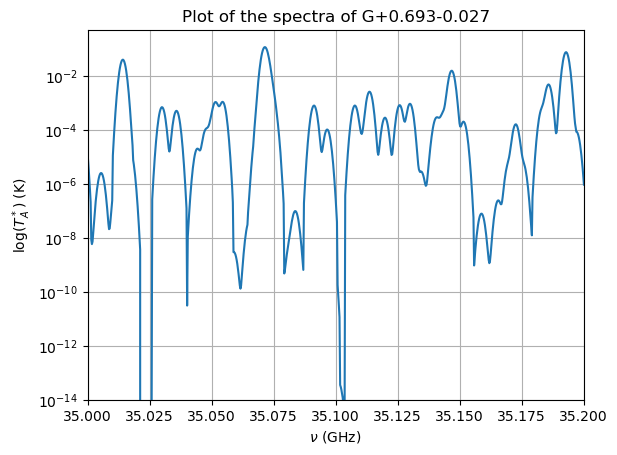

In [70]:
program("plot_spectra")

In [ ]:
#plot_spectra
#The selected parameters used for the outlook
#GHz,1,log,1
#35,35.2,1e-14,0.5

In [25]:
program("frequency_lines",1) #poner transiciones de cada molecula, prioridad ultima

Want some other parameters for this tool? If not, it will be filled by default values. 
 No


saved as: %peaks.txt%


In [ ]:
#frequency_lines
#The selected parameters used for the outlook
#1e-1,0,1,0,GHz

In [29]:
program("mol_detection",1) #cambiar eje y y poner nombre moleculas que se vea

Want some other parameters for this tool? If not, it will be filled by default values. 
 Yes
Please put all the parameters here, separated by commas and without blanks. Check help if you want to fill all with your preferences.
 The parameters for 'mol_detection' are: 
 (molecules_search,error,hmin,threshold,distance,prominence,grid,y_scale,w_units,zoom) 
 select,5e-3,1e-2,0,1,0,1,linear,GHz,1


['select', '5e-3', '1e-2', '0', '1', '0', '1', 'linear', 'GHz', '1']


Where do you want the zooming? Put the values of xmin, xmax, ymin, ymax. Separate all the values by commas 
 40,45,0,0.5
Which molecules you want to identify from the spectra? Separate them by commas 
 CH3OCH3,HNCO,SiO,HCOOH,CH3OH,C2H5CN,CH2NH,HC7N


<Figure size 640x480 with 0 Axes>

saved as: %spectra_g0693_selected.svg%


In [ ]:
#mol_detection
#The selected parameters used for the outlook
#select,5e-3,1e-2,0,1,0,1,linear,GHz,1
#CH3OCH3,HNCO,SiO,HCOOH,CH3OH,C2H5CN,CH2NH,HC7N
#40,45,0,0.5

In [48]:
program("density_lines")

Want some other parameters for this tool? If not, it will be filled by default values. 
 Yes
Please put all the parameters here, separated by commas and without blanks. Check help if you want to fill all with your preferences.
 The parameters for 'density_lines' are: 
 (hmin,threshold,distance,prominence,w_units,search_method,distance of arange/number of blocks) 
 1e-2,0,1,0,GHz,blocks,20


['1e-2', '0', '1', '0', 'GHz', 'blocks', '20']
['1e-2', '0', '1', '0', 'GHz', 'blocks', '20']
['1e-2', '0', '1', '0', 'GHz', 'blocks', '20']


([32.09313034139378,
  33.11158084205218,
  34.13003134271057,
  35.14848184336897,
  36.166932344027366,
  37.18538284468576,
  38.20383334534416,
  39.222283846002554,
  40.24073434666096,
  41.259184847319354,
  42.27763534797775,
  43.296085848636146,
  44.31453634929454,
  45.33298684995294,
  46.351437350611334,
  47.36988785126974,
  48.38833835192813,
  49.40678885258653],
 [11.29166316140607,
  16.201081927234824,
  22.092384446229307,
  24.0561519525608,
  23.565210075977927,
  24.0561519525608,
  23.074268199395053,
  21.601442569646355,
  22.09238444622923,
  18.164849433566317,
  15.710140050651951,
  24.0561519525608,
  23.074268199395053,
  20.12861693989781,
  23.07426819939497,
  23.074268199395053,
  22.092384446229307,
  21.110500693063486])

In [ ]:
#density_lines
#The selected parameters used for the outlook
#1e-2,0,1,0,GHz,equispace,0.5

Want some other parameters for this tool? If not, it will be filled by default values. 
 Yes
Please put all the parameters here, separated by commas and without blanks. Check help if you want to fill all with your preferences.
 The parameters for 'histogram' are: 
 (hmin,threshold,distance,prominence,w_units,search_method,distance of arange/number of blocks) 
 1e-2,0,1,0,GHz,equispace,0.1


['1e-2', '0', '1', '0', 'GHz', 'equispace', '0.1']


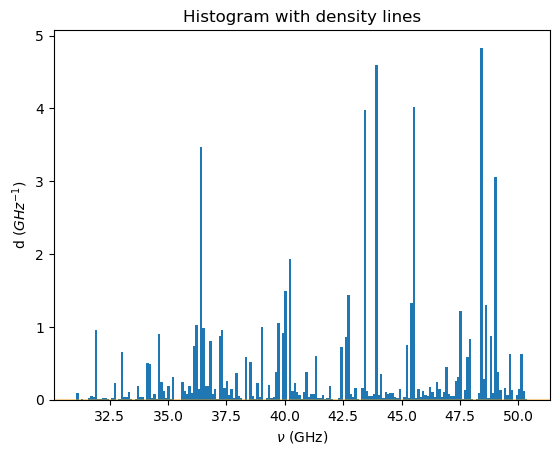

In [5]:
program("histogram") #poner varios histogramas en la misma figura con distinto ancho

In [ ]:
#histogram
#The selected parameters used for the outlook
#1e-2,0,1,0,GHz,equispace,0.5

Want some other parameters for this tool? If not, it will be filled by default values. 
 Yes
Please put all the parameters here, separated by commas and without blanks. Check help if you want to fill all with your preferences.
 The parameters for 'subplots_low_lines' are: 
 (grid,y_scale,intensityaverage_pass,hmin,threshold,distance,prominence,w_units,search_method,distance of arange/number of blocks) 
 1,linear,5,1e-2,0,1,0,GHz,max_I,blocks,40


['1', 'linear', '5', '1e-2', '0', '1', '0', 'GHz', 'max_I', 'blocks', '40']


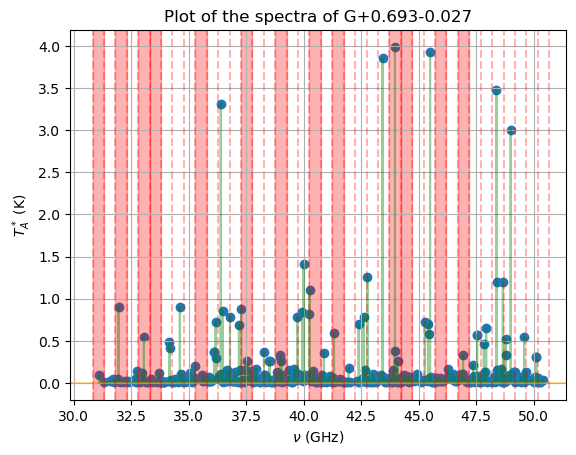

saved as: %subplots_general_spectra_g0693.svg%


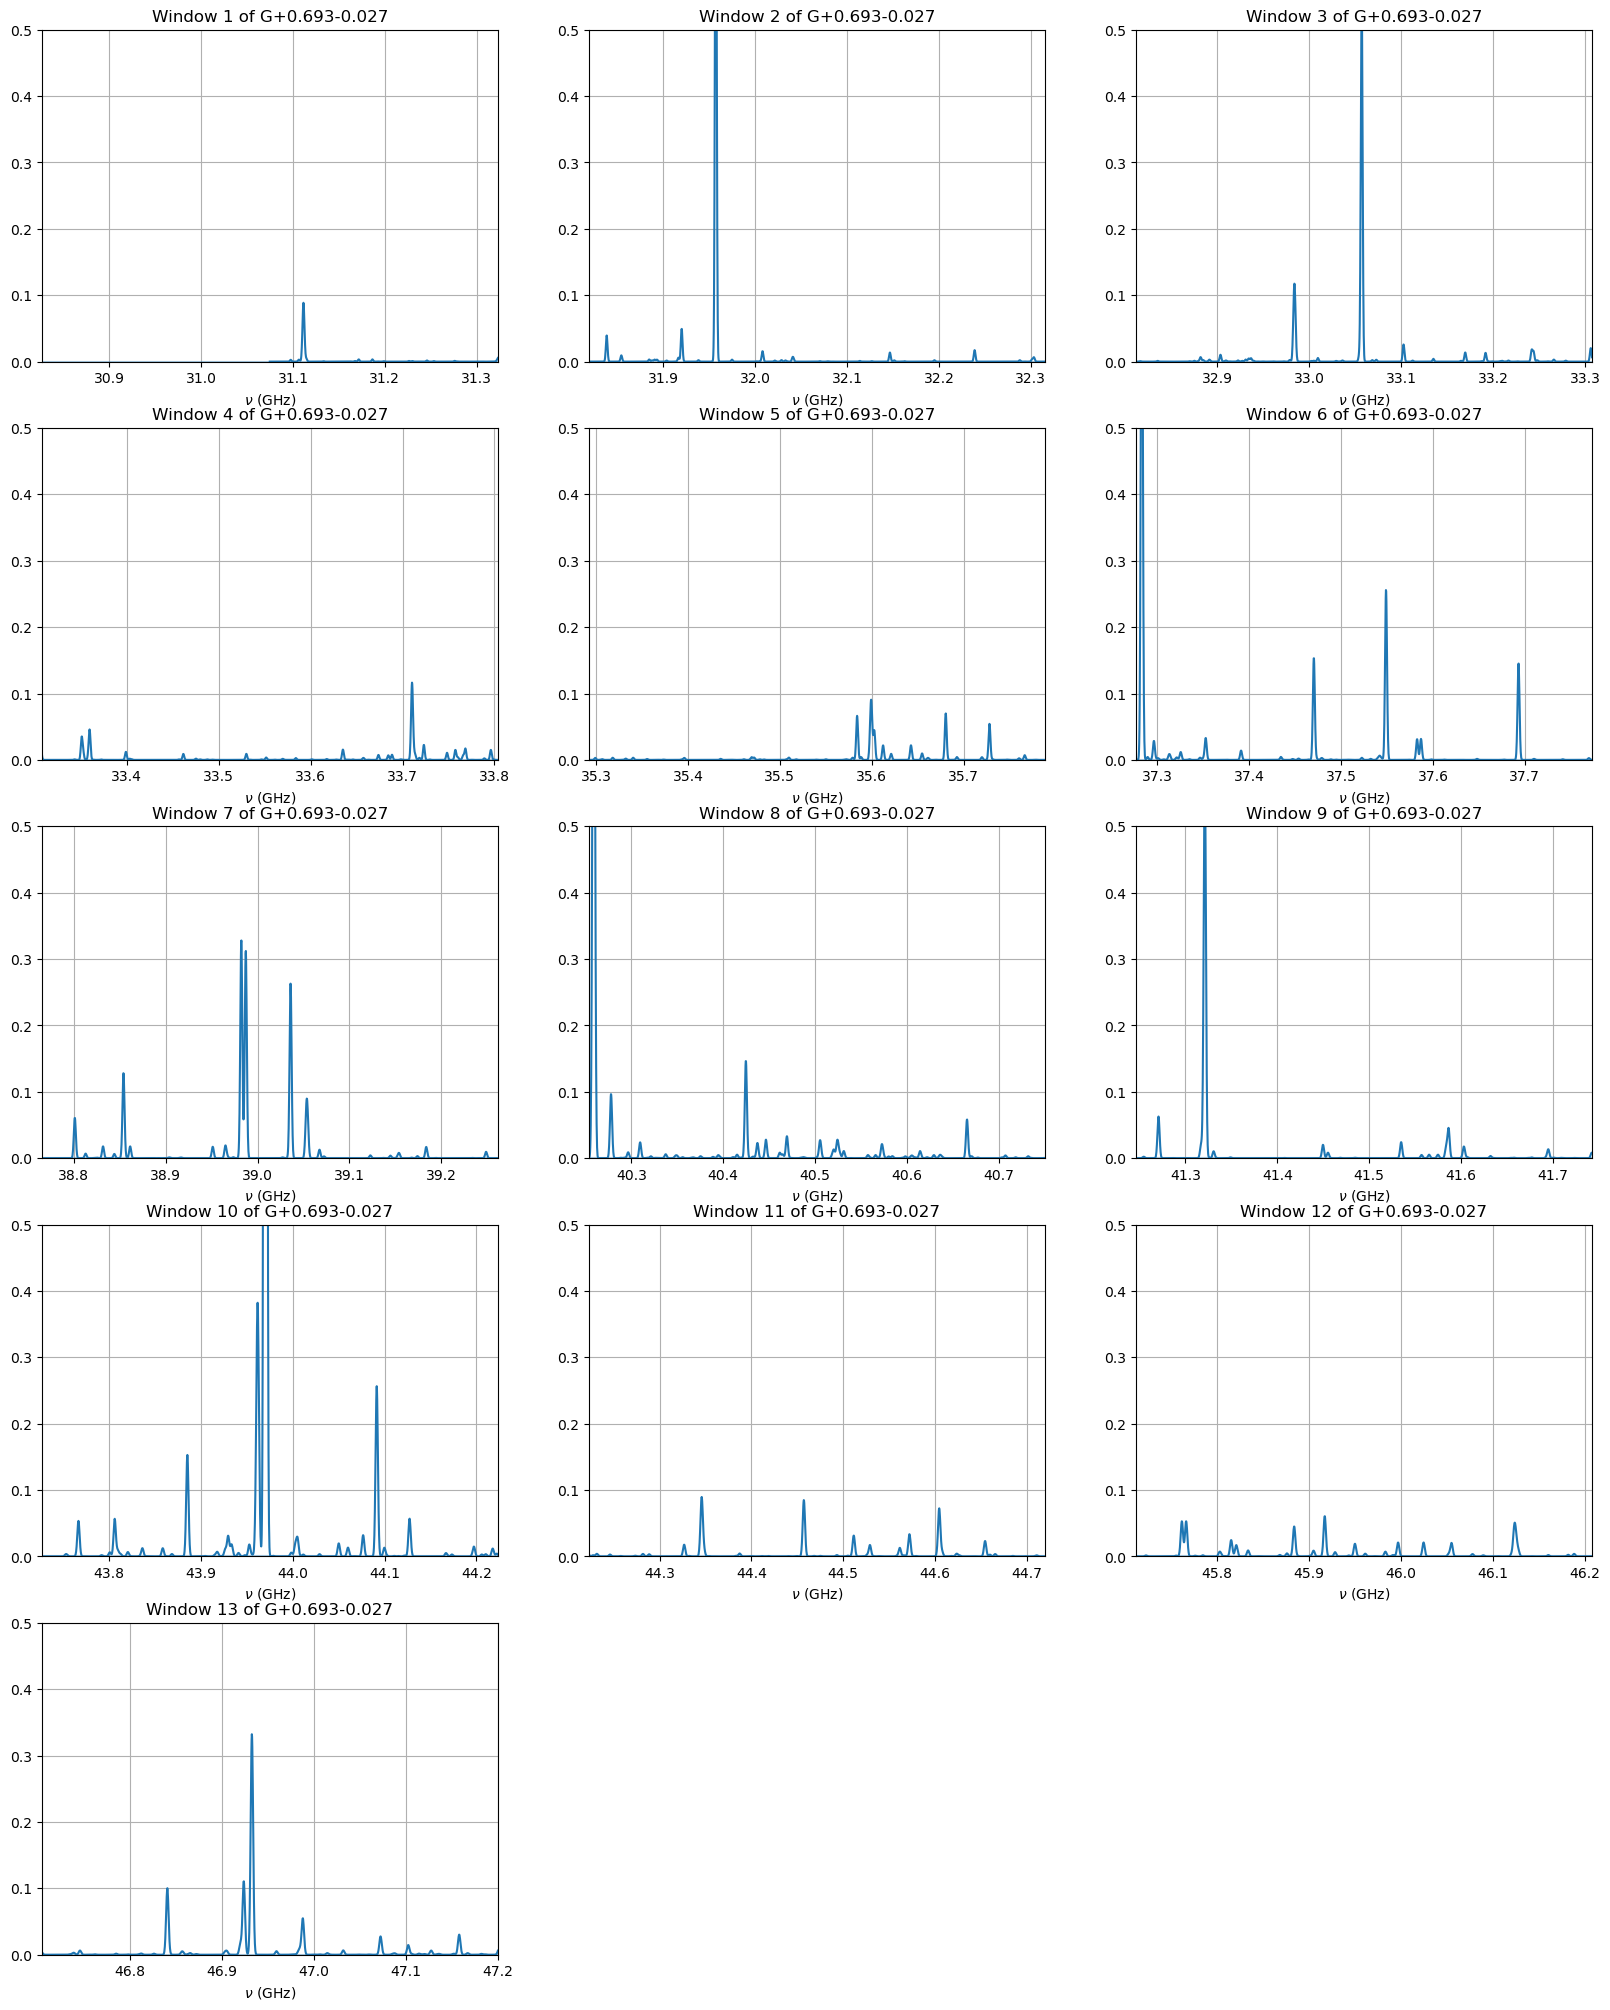

saved as: %subplots_lowlines_spectra_g0693.svg%


In [76]:
program("subplots_low_lines",1)

In [ ]:
#subplots_low_lines
#The selected parameters used for the outlook
#1,linear,5,1e-2,0,1,0,GHz,max_I,blocks,40

In [ ]:
program("zoom_high_lines")

In [ ]:
#zoom_high_lines
#The selected parameters used for the outlook
#1,linear,5,1e-2,0,1,0,GHz,max_I,blocks,40

Want some other parameters for this tool? If not, it will be filled by default values. 
 Yes
Please put all the parameters here, separated by commas and without blanks. Check help if you want to fill all with your preferences.
 The parameters for 'zoom_low_lines' are: 
 (grid,y_scale,intensityaverage_pass,hmin,threshold,distance,prominence,w_units,search_method,distance of arange/number of blocks) 
 1,linear,5,1e-2,0,1,0,GHz,max_I,blocks,40


['1', 'linear', '5', '1e-2', '0', '1', '0', 'GHz', 'max_I', 'blocks', '40']


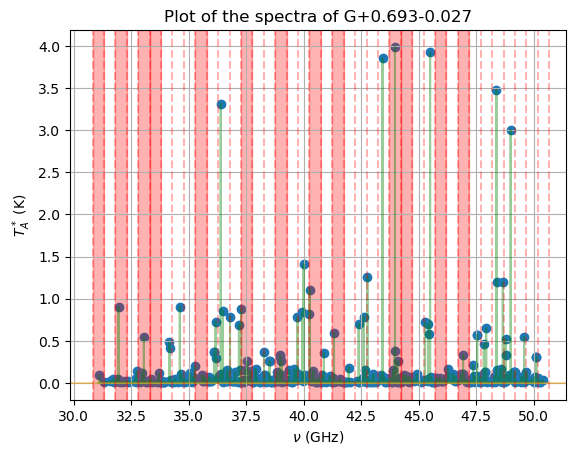

There are 13 windows


Do you want to choose any window? Choose 'Yes' or 'No' for this question. 
 Yes
Which window do you want to choose? From 1 to 13 
 10


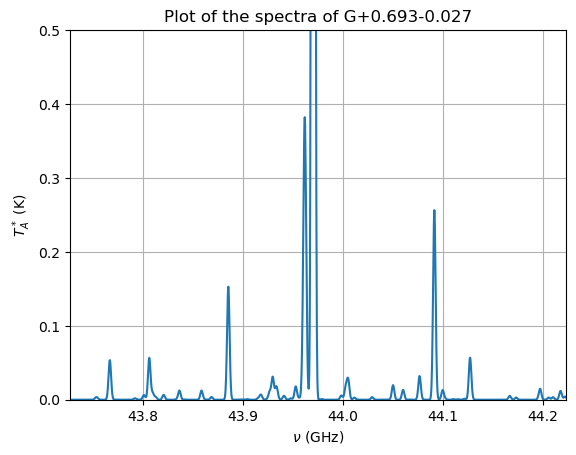

In [82]:
program("zoom_low_lines")

In [94]:
#zoom_low_lines
#The selected parameters used for the outlook
#1,linear,5,1e-2,0,1,0,GHz,max_I,blocks,40

Want some other parameters for this tool? If not, it will be filled by default values. 
 Yes
Please put all the parameters here, separated by commas and without blanks. Check help if you want to fill all with your preferences.
 The parameters for 'gaussian_kde_map' are: 
 (w_units,grid,y_scale,gaussian_method) 
 GHz,1,linear,0.03


['GHz', '1', 'linear', '0.03']


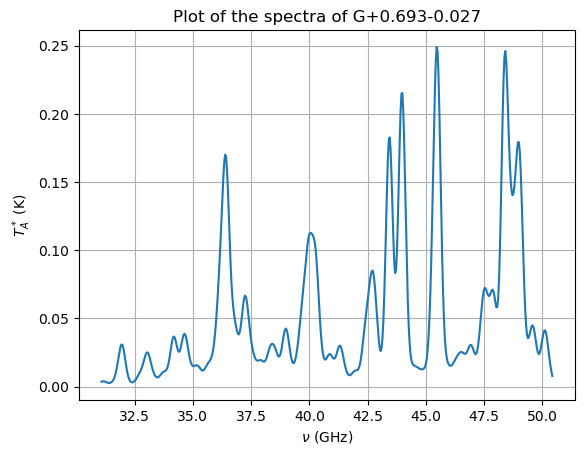

In [52]:
program("gaussian_kde_map")

In [ ]:
#gaussian_kde_map
#The selected parameters used for the outlook
#GHz,1,linear,0.03